# Full Preprocessing Pipeline (Corrected Order)

Converts `all_cases_labeled.csv` into model-ready arrays for the VAE.

**Correct Pipeline Order:**
```
all_cases_labeled.csv
        |
  [1] CLEAN       per container: dedup timestamps + mark gap boundaries
        |
  [2] WINDOW      sliding window size=30, stride=1  ->  shape: (N, 30, 7)
        |           skip windows that span time gaps
  [3] FLATTEN     each window  (30 x 7)  ->  (210,)
        |
  [4] PCA         fit on training normal windows only
        |           (210,)  ->  (n_components,)   ~95% variance
  [5] SPLIT       train / val / test_simple / test_drift
        |
  [6] SAVE        .npy arrays + pca model
```

**Why this order?**  
- Window first captures **temporal + feature** patterns together in one flat vector (210 dims)  
- PCA then compresses that full spatio-temporal representation  
- VAE reconstructs the PCA-compressed window â€” any deviation = anomaly score

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os
from sklearn.decomposition import PCA

BASE        = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3\data'
IN_PATH     = os.path.join(BASE, 'processed', 'all_cases_labeled.csv')
OUT_DIR     = os.path.join(BASE, 'processed', 'windows')
os.makedirs(OUT_DIR, exist_ok=True)

WINDOW_SIZE  = 30       # 30 timesteps x 15s = 7.5 minutes
STRIDE       = 1        # rolling window
GAP_THRESH   = 30       # seconds â€” time_diff above this = gap boundary
PCA_VARIANCE = 0.95     # keep components explaining 95% variance

FEATURE_COLS = [
    'container_cpu_usage_seconds_rate',
    'container_cpu_system_seconds_rate',
    'container_cpu_user_seconds_rate',
    'container_memory_usage_bytes',
    'container_memory_working_set_bytes',
    'container_memory_rss',
    'container_memory_cache',
]

N_FEATURES   = len(FEATURE_COLS)                  # 7
FLAT_SIZE    = WINDOW_SIZE * N_FEATURES            # 210

print('Config ready.')
print(f'  Window size      : {WINDOW_SIZE} steps  ({WINDOW_SIZE*15//60} min {WINDOW_SIZE*15%60} sec)')
print(f'  Features per step: {N_FEATURES}')
print(f'  Flattened size   : {FLAT_SIZE}  (= {WINDOW_SIZE} x {N_FEATURES})')
print(f'  Output dir       : {OUT_DIR}')

Config ready.
  Window size      : 30 steps  (7 min 30 sec)
  Features per step: 7
  Flattened size   : 210  (= 30 x 7)
  Output dir       : c:\Users\jthar\Documents\Claude\Projects\module3\data\processed\windows


---
## Step 1 â€” Load and Clean
Remove duplicate timestamps and mark gap boundaries **per container**.

In [64]:
print('Loading merged labeled file ...')
raw = pd.read_csv(IN_PATH, low_memory=False)
print(f'Loaded : {len(raw):,} rows x {raw.shape[1]} columns')
print(f'Cases  : {raw["case"].unique().tolist()}')
raw.head(3)

Loading merged labeled file ...
Loaded : 533,230 rows x 12 columns
Cases  : ['single_case1', 'single_case2', 'complex_case1', 'complex_case2']


,timestamp,cmdb_id,case,container_cpu_usage_seconds_rate,container_cpu_system_seconds_rate,container_cpu_user_seconds_rate,container_memory_usage_bytes,container_memory_working_set_bytes,container_memory_rss,container_memory_cache,label,failure_type
0,1719252015,observe.cartservice-0,single_case1,2.242894,2.595977,2.197721,-1.252447,-1.25156,-1.301874,-0.612205,0,NaN
1,1719252030,observe.cartservice-0,single_case1,-0.471981,-0.462826,-0.448592,-1.252447,-1.25156,-1.301874,-0.612205,0,NaN
2,1719252045,observe.cartservice-0,single_case1,-0.471981,-0.462826,-0.448592,-1.252447,-1.25156,-1.301874,-0.612205,0,NaN


In [65]:
def clean_container(c_df):
    """Sort, deduplicate, and flag gap boundaries for one container's data."""
    c = c_df.sort_values('timestamp').copy()
    c = c.drop_duplicates(subset='timestamp', keep='first').reset_index(drop=True)
    c['time_diff'] = c['timestamp'].diff().fillna(15)  # first row: no gap
    c['is_gap']    = c['time_diff'] > GAP_THRESH       # True = break in time series
    return c

print('Cleaning per container ...')
cleaned_parts = []
clean_stats   = []

for case in ['single_case1', 'single_case2', 'complex_case1', 'complex_case2']:
    case_df = raw[raw['case'] == case]
    parts   = [clean_container(case_df[case_df['cmdb_id'] == cid])
               for cid in case_df['cmdb_id'].unique()]
    clean   = pd.concat(parts, ignore_index=True)
    removed = len(case_df) - len(clean)
    gaps    = int(clean['is_gap'].sum())
    cleaned_parts.append(clean)
    clean_stats.append({'case': case, 'original': len(case_df),
                        'after_dedup': len(clean), 'dups_removed': removed, 'gap_boundaries': gaps})
    print(f'  {case}: {len(case_df):>7,} -> {len(clean):>7,} rows  '
          f'dups_removed={removed:>6,}  gap_boundaries={gaps}')

df = pd.concat(cleaned_parts, ignore_index=True)
print(f'\nTotal clean rows: {len(df):,}')
pd.DataFrame(clean_stats)

Cleaning per container ...
  single_case1:  74,196 ->  60,480 rows  dups_removed=13,716  gap_boundaries=0
  single_case2:  45,711 ->  38,853 rows  dups_removed= 6,858  gap_boundaries=0
  complex_case1: 318,418 -> 223,803 rows  dups_removed=94,615  gap_boundaries=54
  complex_case2:  94,905 ->  77,760 rows  dups_removed=17,145  gap_boundaries=0

Total clean rows: 400,896


,case,original,after_dedup,dups_removed,gap_boundaries
0,single_case1,74196,60480,13716,0
1,single_case2,45711,38853,6858,0
2,complex_case1,318418,223803,94615,54
3,complex_case2,94905,77760,17145,0


---
## Label Check — Before Sliding Window
Verify label 0 (normal) and label 1 (anomaly) counts **after cleaning** but **before windowing**.  
This confirms the class imbalance and that deduplication did not corrupt any labels.

In [66]:
print("=" * 65)
print("LABEL DISTRIBUTION - AFTER CLEANING, BEFORE SLIDING WINDOW")
print("=" * 65)

# Overall counts
total  = len(df)
l0_all = (df["label"] == 0).sum()
l1_all = (df["label"] == 1).sum()

print()
print("OVERALL")
print(f"  Label 0 - Normal  : {l0_all:>7,}  ({l0_all/total*100:.2f}%)")
print(f"  Label 1 - Anomaly : {l1_all:>7,}  ({l1_all/total*100:.2f}%)")
print(f"  Total             : {total:>7,}")

# Per case counts
print()
print("PER CASE")
rows = []
for case in ["single_case1", "single_case2", "complex_case1", "complex_case2"]:
    sub = df[df["case"] == case]
    l0  = (sub["label"] == 0).sum()
    l1  = (sub["label"] == 1).sum()
    tot = len(sub)
    rows.append({"Case": case, "Normal(0)": l0, "Anomaly(1)": l1,
                 "Total": tot, "Anomaly%": round(l1/tot*100, 2)})
    print(f"  {case}:")
    print(f"    Label 0 - Normal  : {l0:>7,}  ({l0/tot*100:.2f}%)")
    print(f"    Label 1 - Anomaly : {l1:>7,}  ({l1/tot*100:.2f}%)")
    print(f"    Total             : {tot:>7,}")

print()
print("Summary Table:")
display(pd.DataFrame(rows).set_index("Case"))

# Per case x failure type
print()
print("ANOMALY ROWS BY FAULT TYPE")
for case in ["single_case1", "single_case2", "complex_case1", "complex_case2"]:
    sub = df[(df["case"] == case) & (df["label"] == 1)]
    ft_counts = sub["failure_type"].value_counts()
    print(f"  {case}:")
    if len(ft_counts) == 0:
        print("    (no anomaly rows)")
    else:
        for ft, cnt in ft_counts.items():
            print(f"    {ft:15s}: {cnt:>5,} rows")

# Gap boundaries
print()
print("GAP BOUNDARIES (is_gap=True)")
for case in ["single_case1", "single_case2", "complex_case1", "complex_case2"]:
    gaps = int(df[df["case"] == case]["is_gap"].sum())
    print(f"  {case}: {gaps} gap boundaries")

print()
print(f"NOTE: {l1_all/total*100:.2f}% anomaly rate -> severe class imbalance")
print("This justifies the unsupervised VAE approach.")


LABEL DISTRIBUTION - AFTER CLEANING, BEFORE SLIDING WINDOW

OVERALL
  Label 0 - Normal  : 399,432  (99.63%)
  Label 1 - Anomaly :   1,464  (0.37%)
  Total             : 400,896

PER CASE
  single_case1:
    Label 0 - Normal  :  60,364  (99.81%)
    Label 1 - Anomaly :     116  (0.19%)
    Total             :  60,480
  single_case2:
    Label 0 - Normal  :  38,797  (99.86%)
    Label 1 - Anomaly :      56  (0.14%)
    Total             :  38,853
  complex_case1:
    Label 0 - Normal  : 223,323  (99.79%)
    Label 1 - Anomaly :     480  (0.21%)
    Total             : 223,803
  complex_case2:
    Label 0 - Normal  :  76,948  (98.96%)
    Label 1 - Anomaly :     812  (1.04%)
    Total             :  77,760

Summary Table:


,Normal(0),Anomaly(1),Total,Anomaly%
Case,,,,
single_case1,60364,116,60480,0.19
single_case2,38797,56,38853,0.14
complex_case1,223323,480,223803,0.21
complex_case2,76948,812,77760,1.04



ANOMALY ROWS BY FAULT TYPE
  single_case1:
    memory         :    40 rows
    loss           :    40 rows
    cpu            :    36 rows
  single_case2:
    pod-failure    :    56 rows
  complex_case1:
    delay          :   124 rows
    loss           :   100 rows
    pod-failure    :    92 rows
    cpu            :    88 rows
    memory         :    76 rows
  complex_case2:
    loss           :   360 rows
    memory         :   240 rows
    cpu            :   120 rows
    delay          :    80 rows
    pod-failure    :    12 rows

GAP BOUNDARIES (is_gap=True)
  single_case1: 0 gap boundaries
  single_case2: 0 gap boundaries
  complex_case1: 54 gap boundaries
  complex_case2: 0 gap boundaries

NOTE: 0.37% anomaly rate -> severe class imbalance
This justifies the unsupervised VAE approach.


---
## Step 2 â€” Sliding Window  
Build rolling windows of size 30 per container per case.  
Each window spans 30 consecutive 15-second timesteps = **7.5 minutes**.  
Windows crossing a gap boundary are **skipped**.

In [67]:
def build_windows(container_df, window_size, feature_cols):
    """
    Slide a window of `window_size` over one container's clean time series.
    Returns:
      X  : (N, window_size, n_features)  raw feature windows
      y  : (N,)  1 if any anomaly in window else 0
      ft : (N,)  failure_type of anomaly in window (or NaN)
    """
    data   = container_df[feature_cols].values.astype(np.float32)
    labels = container_df['label'].values
    ftypes = container_df['failure_type'].values.astype(str)
    is_gap = container_df['is_gap'].values
    n      = len(data)

    X, y, ft = [], [], []
    for i in range(n - window_size):
        if is_gap[i : i + window_size].any():      # skip gap-spanning windows
            continue
        X.append(data[i : i + window_size])        # shape: (30, 7)
        y.append(int(labels[i : i + window_size].any()))
        w_ft   = ftypes[i : i + window_size]
        anomaly = [v for v in w_ft if v not in ('nan', 'NaN', 'None', '')]
        ft.append(anomaly[0] if anomaly else np.nan)

    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.int8),
            np.array(ft, dtype=object))

print(f'Building sliding windows (size={WINDOW_SIZE}, stride={STRIDE}) ...')
print()

case_windows = {}
for case in ['single_case1', 'single_case2', 'complex_case1', 'complex_case2']:
    case_df             = df[df['case'] == case]
    X_list, y_list, ft_list = [], [], []

    for cid in sorted(case_df['cmdb_id'].unique()):
        c = case_df[case_df['cmdb_id'] == cid].sort_values('timestamp').reset_index(drop=True)
        Xc, yc, ftc = build_windows(c, WINDOW_SIZE, FEATURE_COLS)
        if len(Xc) > 0:
            X_list.append(Xc); y_list.append(yc); ft_list.append(ftc)

    X  = np.concatenate(X_list, axis=0)   # (N, 30, 7)
    y  = np.concatenate(y_list, axis=0)
    ft = np.concatenate(ft_list, axis=0)
    case_windows[case] = {'X': X, 'y': y, 'ft': ft}

    print(f'  {case}:')
    print(f'    Windows shape   : {X.shape}  (windows, timesteps, features)')
    print(f'    Anomaly windows : {y.sum():,}  ({y.mean()*100:.2f}%)')
    print()

Building sliding windows (size=30, stride=1) ...



  single_case1:
    Windows shape   : (59670, 30, 7)  (windows, timesteps, features)
    Anomaly windows : 203  (0.34%)

  single_case2:
    Windows shape   : (38043, 30, 7)  (windows, timesteps, features)
    Anomaly windows : 85  (0.22%)

  complex_case1:
    Windows shape   : (221495, 30, 7)  (windows, timesteps, features)
    Anomaly windows : 783  (0.35%)

  complex_case2:
    Windows shape   : (76950, 30, 7)  (windows, timesteps, features)
    Anomaly windows : 1,479  (1.92%)



---
### Window Check - Normal vs Anomaly Count Per Case
Verify window label distribution after sliding window construction.

WINDOW CHECK - AFTER SLIDING WINDOW (size=30, stride=1)

  single_case1
    Total windows   :  59,670
    Normal  (y=0)   :  59,467  (99.66%)
    Anomaly (y=1)   :     203  (0.34%)
    Fault type breakdown:
      memory         :    40 windows
      loss           :    40 windows
      cpu            :    36 windows

  single_case2
    Total windows   :  38,043
    Normal  (y=0)   :  37,958  (99.78%)
    Anomaly (y=1)   :      85  (0.22%)
    Fault type breakdown:
      pod-failure    :    56 windows

  complex_case1
    Total windows   : 221,495
    Normal  (y=0)   : 220,712  (99.65%)
    Anomaly (y=1)   :     783  (0.35%)
    Fault type breakdown:
      delay          :   124 windows
      loss           :   100 windows
      pod-failure    :    92 windows
      cpu            :    88 windows
      memory         :    60 windows

  complex_case2
    Total windows   :  76,950
    Normal  (y=0)   :  75,471  (98.08%)
    Anomaly (y=1)   :   1,479  (1.92%)
    Fault type breakdown:
     

,Total,Normal(y=0),Anomaly(y=1),Anomaly %
Case,,,,
single_case1,59670,59467,203,0.34
single_case2,38043,37958,85,0.22
complex_case1,221495,220712,783,0.35
complex_case2,76950,75471,1479,1.92


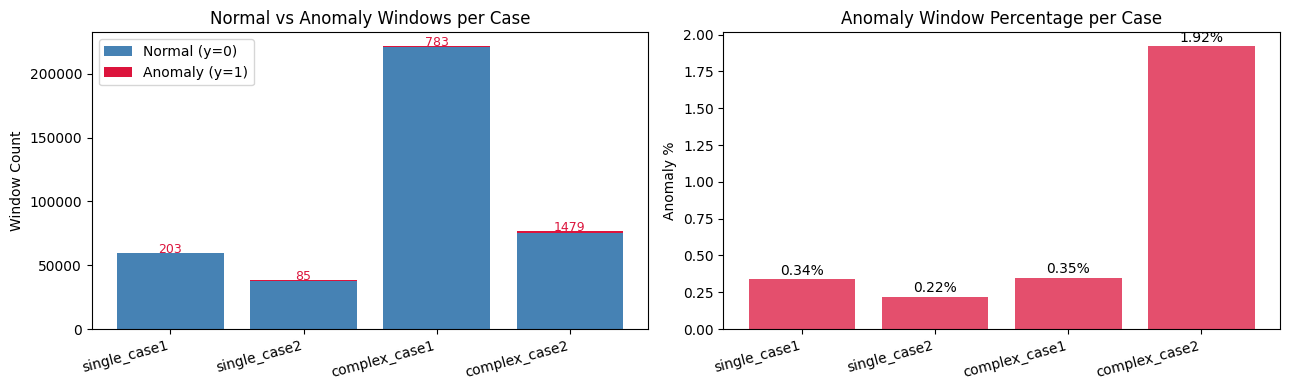

Chart saved.


In [68]:
print("=" * 65)
print("WINDOW CHECK - AFTER SLIDING WINDOW (size=30, stride=1)")
print("=" * 65)

all_rows = []
total_normal  = 0
total_anomaly = 0
total_windows = 0

for case in ["single_case1", "single_case2", "complex_case1", "complex_case2"]:
    y         = case_windows[case]["y"]
    ft        = case_windows[case]["ft"]
    n_total   = len(y)
    n_normal  = int((y == 0).sum())
    n_anomaly = int((y == 1).sum())

    total_normal  += n_normal
    total_anomaly += n_anomaly
    total_windows += n_total

    print()
    print(f"  {case}")
    print(f"    Total windows   : {n_total:>7,}")
    print(f"    Normal  (y=0)   : {n_normal:>7,}  ({n_normal/n_total*100:.2f}%)")
    print(f"    Anomaly (y=1)   : {n_anomaly:>7,}  ({n_anomaly/n_total*100:.2f}%)")

    # Breakdown by failure type inside anomaly windows
    import collections
    ft_count = collections.Counter([str(v) for v in ft[y == 1] if str(v) != "nan"])
    if ft_count:
        print(f"    Fault type breakdown:")
        for ftype, cnt in sorted(ft_count.items(), key=lambda x: -x[1]):
            print(f"      {ftype:15s}: {cnt:>5,} windows")

    all_rows.append({
        "Case"       : case,
        "Total"      : n_total,
        "Normal(y=0)": n_normal,
        "Anomaly(y=1)": n_anomaly,
        "Anomaly %"  : round(n_anomaly / n_total * 100, 2)
    })

# Overall summary
print()
print("=" * 65)
print("OVERALL SUMMARY")
print(f"  Total windows   : {total_windows:>7,}")
print(f"  Normal  (y=0)   : {total_normal:>7,}  ({total_normal/total_windows*100:.2f}%)")
print(f"  Anomaly (y=1)   : {total_anomaly:>7,}  ({total_anomaly/total_windows*100:.2f}%)")

# Summary table
print()
print("Summary Table:")
display(pd.DataFrame(all_rows).set_index("Case"))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cases      = [r["Case"] for r in all_rows]
normals    = [r["Normal(y=0)"] for r in all_rows]
anomalies  = [r["Anomaly(y=1)"] for r in all_rows]
pcts       = [r["Anomaly %"] for r in all_rows]
x          = range(len(cases))

# Left: stacked bar - normal vs anomaly count
axes[0].bar(x, normals,   label="Normal (y=0)",  color="steelblue")
axes[0].bar(x, anomalies, label="Anomaly (y=1)", color="crimson", bottom=normals)
axes[0].set_xticks(x)
axes[0].set_xticklabels(cases, rotation=15, ha="right")
axes[0].set_ylabel("Window Count")
axes[0].set_title("Normal vs Anomaly Windows per Case")
axes[0].legend()
for i, (n, a) in enumerate(zip(normals, anomalies)):
    axes[0].text(i, n + a + 200, str(a), ha="center", color="crimson", fontsize=9)

# Right: anomaly percentage
bars = axes[1].bar(x, pcts, color="crimson", alpha=0.75)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cases, rotation=15, ha="right")
axes[1].set_ylabel("Anomaly %")
axes[1].set_title("Anomaly Window Percentage per Case")
for bar, pct in zip(bars, pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{pct}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "window_label_distribution.png"), dpi=100)
plt.show()
print("Chart saved.")


---
### Sample Window Viewer
Shows one normal window and one anomaly window with timesteps (t1...t30), datetime, and metric values.

In [69]:
# Short column names for display
SHORT_NAMES = {
    "container_cpu_usage_seconds_rate"   : "cpu_usage",
    "container_cpu_system_seconds_rate"  : "cpu_system",
    "container_cpu_user_seconds_rate"    : "cpu_user",
    "container_memory_usage_bytes"       : "mem_usage",
    "container_memory_working_set_bytes" : "mem_wset",
    "container_memory_rss"               : "mem_rss",
    "container_memory_cache"             : "mem_cache",
}

def show_window(case_name, container_id, start_idx, df_clean, label_tag):
    """Print a single window in t1...t30 format with datetime and metrics."""
    sub = df_clean[
        (df_clean["case"]    == case_name) &
        (df_clean["cmdb_id"] == container_id)
    ].sort_values("timestamp").reset_index(drop=True)

    window = sub.iloc[start_idx : start_idx + WINDOW_SIZE].copy()
    window = window.reset_index(drop=True)

    print(f"Case     : {case_name}")
    print(f"Container: {container_id}")
    print(f"Label    : {label_tag}")
    print(f"Window   : t1 = {window['datetime'].iloc[0]}  "
          f"t30 = {window['datetime'].iloc[-1]}")
    print()

    rows = []
    for i, row in window.iterrows():
        r = {"step": f"t{i+1:02d}", "datetime": row["datetime"]}
        for col, short in SHORT_NAMES.items():
            r[short] = round(row[col], 4)
        r["label"] = int(row["label"])
        rows.append(r)

    display(pd.DataFrame(rows).set_index("step"))


# Load clean file with datetime column
CLEAN_PATH = os.path.join(BASE, "processed", "all_cases_clean.csv")
df_clean   = pd.read_csv(CLEAN_PATH, low_memory=False)

# ---- Normal Window (single_case1, cartservice-0) ----
print("=" * 70)
print("NORMAL WINDOW EXAMPLE (label=0)")
print("=" * 70)
show_window("single_case1", "observe.cartservice-0", start_idx=10,
            df_clean=df_clean, label_tag="Normal (all 30 steps = 0)")

print()

# ---- Anomaly Window: pick a container that has anomaly rows ----
# Find first anomaly row in single_case1 paymentservice-0 (has cpu fault)
anom_sub = df_clean[
    (df_clean["case"]    == "single_case1") &
    (df_clean["cmdb_id"] == "observe.paymentservice-1") &
    (df_clean["label"]   == 1)
].sort_values("timestamp").reset_index(drop=True)

if len(anom_sub) > 0:
    # Get index of first anomaly in that container series
    cont_sub = df_clean[
        (df_clean["case"]    == "single_case1") &
        (df_clean["cmdb_id"] == "observe.paymentservice-1")
    ].sort_values("timestamp").reset_index(drop=True)

    first_anom_ts = anom_sub["timestamp"].iloc[0]
    anom_idx = cont_sub[cont_sub["timestamp"] == first_anom_ts].index[0]
    # Start window 5 steps before anomaly so we see the transition
    start = max(0, anom_idx - 5)

    print("=" * 70)
    print("ANOMALY WINDOW EXAMPLE (label=1)")
    print("=" * 70)
    show_window("single_case1", "observe.paymentservice-1", start_idx=start,
                df_clean=df_clean,
                label_tag=f"Anomaly ({anom_sub['failure_type'].iloc[0]} fault)")
else:
    print("No anomaly rows found for paymentservice-0 in single_case1")


NORMAL WINDOW EXAMPLE (label=0)
Case     : single_case1
Container: observe.cartservice-0
Label    : Normal (all 30 steps = 0)
Window   : t1 = 2024-06-24 18:02:45  t30 = 2024-06-24 18:10:00



,datetime,cpu_usage,cpu_system,cpu_user,mem_usage,mem_wset,mem_rss,mem_cache,label
step,,,,,,,,,
t01,2024-06-24 18:02:45,-0.4720,-0.4628,-0.4486,-1.1958,-1.1947,-1.2793,-0.6122,0
t02,2024-06-24 18:03:00,1.6343,0.8830,1.2478,-1.3760,-1.3757,-1.3639,-0.6122,0
t03,2024-06-24 18:03:15,-0.4720,-0.4628,-0.4486,-1.3760,-1.3757,-1.3639,-0.6122,0
t04,2024-06-24 18:03:30,-0.4720,-0.4628,-0.4486,-1.3760,-1.3757,-1.3639,-0.6122,0
t05,2024-06-24 18:03:45,-0.4720,-0.4628,-0.4486,-1.3760,-1.3757,-1.3639,-0.6122,0
t06,2024-06-24 18:04:00,-0.4720,-0.4628,-0.4486,-1.3760,-1.3757,-1.3639,-0.6122,0
t07,2024-06-24 18:04:15,2.8004,1.9842,2.6048,-1.1855,-1.1843,-1.2737,-0.6122,0
t08,2024-06-24 18:04:30,-0.4720,-0.4628,-0.4486,-1.1855,-1.1843,-1.2737,-0.6122,0
t09,2024-06-24 18:04:45,-0.4720,-0.4628,-0.4486,-1.1855,-1.1843,-1.2737,-0.6122,0



ANOMALY WINDOW EXAMPLE (label=1)
Case     : single_case1
Container: observe.paymentservice-1
Label    : Anomaly (cpu fault)
Window   : t1 = 2024-06-24 19:18:45  t30 = 2024-06-24 19:26:00



,datetime,cpu_usage,cpu_system,cpu_user,mem_usage,mem_wset,mem_rss,mem_cache,label
step,,,,,,,,,
t01,2024-06-24 19:18:45,-0.4720,-0.4628,-0.4486,-1.3072,-1.2407,-1.1729,-0.6122,0
t02,2024-06-24 19:19:00,-0.3950,1.7395,-0.4062,-1.0093,-0.8445,-0.6715,-0.6122,0
t03,2024-06-24 19:19:15,-0.4720,-0.4628,-0.4486,-1.0093,-0.8445,-0.6715,-0.6122,0
t04,2024-06-24 19:19:30,-0.4720,-0.4628,-0.4486,-1.0093,-0.8445,-0.6715,-0.6122,0
t05,2024-06-24 19:19:45,-0.4720,-0.4628,-0.4486,-1.0093,-0.8445,-0.6715,-0.6122,0
t06,2024-06-24 19:20:00,-0.4720,-0.4628,-0.4486,-1.0093,-0.8445,-0.6715,-0.6122,1
t07,2024-06-24 19:20:15,-0.3881,2.2289,-0.3949,-1.3639,-1.3161,-1.2690,-0.6122,1
t08,2024-06-24 19:20:30,-0.4720,-0.4628,-0.4486,-1.3639,-1.3161,-1.2690,-0.6122,1
t09,2024-06-24 19:20:45,-0.4720,-0.4628,-0.4486,-1.3639,-1.3161,-1.2690,-0.6122,1


---
## Step 3 â€” Flatten Each Window
Convert each `(30, 7)` window into a flat `(210,)` vector.  
PCA will be applied on these flat vectors.

In [70]:
print('Flattening windows: (N, 30, 7) -> (N, 210) ...')
for case in case_windows:
    X_raw    = case_windows[case]['X']              # (N, 30, 7)
    X_flat   = X_raw.reshape(len(X_raw), -1)       # (N, 210)
    case_windows[case]['X_flat'] = X_flat
    print(f'  {case}: {X_raw.shape} -> {X_flat.shape}')

Flattening windows: (N, 30, 7) -> (N, 210) ...
  single_case1: (59670, 30, 7) -> (59670, 210)
  single_case2: (38043, 30, 7) -> (38043, 210)
  complex_case1: (221495, 30, 7) -> (221495, 210)
  complex_case2: (76950, 30, 7) -> (76950, 210)


---
## Step 4 â€” PCA on Flattened Windows
- Fit PCA **only on normal training windows** (`single_case1`, `label=0`) â€” no data leakage
- Keep components that explain 95% variance
- Transform all windows from all cases

Fitting PCA on 59,467 normal training windows ...
Input dimension: 210 (= 30 timesteps x 7 features)


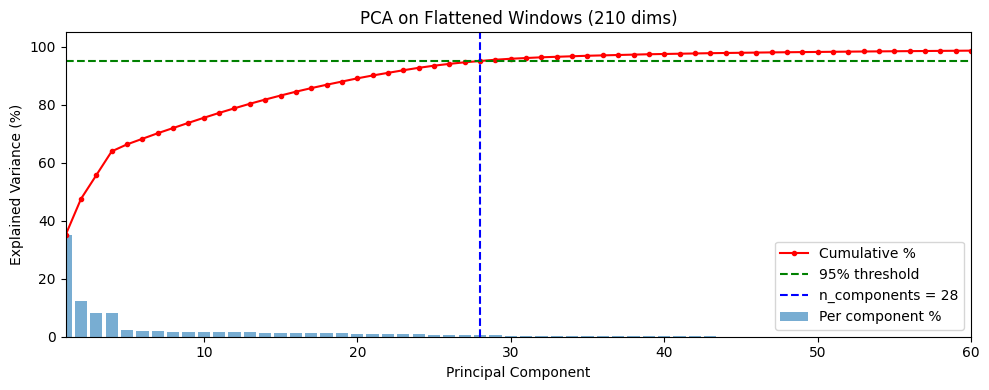


Components needed for 95% variance: 28
Compression: 210 -> 28  (ratio: 7.5x)


In [71]:
# Collect training normal windows
sc1          = case_windows['single_case1']
normal_mask  = sc1['y'] == 0
X_train_flat = sc1['X_flat'][normal_mask]          # (N_normal, 210)

print(f'Fitting PCA on {len(X_train_flat):,} normal training windows ...')
print(f'Input dimension: {X_train_flat.shape[1]} (= 30 timesteps x 7 features)')

# Full PCA to determine n_components
pca_full = PCA()
pca_full.fit(X_train_flat)
cumvar      = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cumvar >= PCA_VARIANCE)) + 1

# Plot explained variance
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_ * 100,
       alpha=0.6, label='Per component %')
ax.plot(range(1, len(cumvar)+1), cumvar * 100, color='red',
        marker='o', markersize=3, label='Cumulative %')
ax.axhline(PCA_VARIANCE * 100, color='green', linestyle='--',
           label=f'{PCA_VARIANCE*100:.0f}% threshold')
ax.axvline(n_components, color='blue', linestyle='--',
           label=f'n_components = {n_components}')
ax.set_xlim(1, 60)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA on Flattened Windows (210 dims)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pca_variance.png'), dpi=100)
plt.show()

print(f'\nComponents needed for {PCA_VARIANCE*100:.0f}% variance: {n_components}')
print(f'Compression: 210 -> {n_components}  (ratio: {210/n_components:.1f}x)')

In [72]:
# Fit final PCA with chosen n_components
pca = PCA(n_components=n_components)
pca.fit(X_train_flat)

# Transform all windows across all cases
print(f'Applying PCA (210 -> {n_components}) to all cases ...')
for case in case_windows:
    X_pca = pca.transform(case_windows[case]['X_flat'])   # (N, n_components)
    case_windows[case]['X_pca'] = X_pca
    print(f'  {case}: {case_windows[case]["X_flat"].shape} -> {X_pca.shape}')

# Save PCA model
pca_path = os.path.join(OUT_DIR, 'pca_model.pkl')
joblib.dump(pca, pca_path)
print(f'\nPCA model saved: {pca_path}')

print(f'\nPCA output stats on training normal windows:')
X_tr_pca = case_windows['single_case1']['X_pca'][normal_mask]
display(pd.DataFrame(X_tr_pca[:, :5],
        columns=[f'PC{i+1}' for i in range(5)]).describe().round(4))

Applying PCA (210 -> 28) to all cases ...
  single_case1: (59670, 210) -> (59670, 28)
  single_case2: (38043, 210) -> (38043, 28)
  complex_case1: (221495, 210) -> (221495, 28)
  complex_case2: (76950, 210) -> (76950, 28)

PCA model saved: c:\Users\jthar\Documents\Claude\Projects\module3\data\processed\windows\pca_model.pkl

PCA output stats on training normal windows:


,PC1,PC2,PC3,PC4,PC5
count,59467.0000,59467.0000,59467.0000,59467.0000,59467.0000
mean,0.0000,0.0000,-0.0000,0.0000,0.0000
std,8.9148,5.3033,4.3125,4.2994,2.3336
min,-14.6702,-8.2324,-8.8333,-8.3303,-7.8110
25%,-7.7252,-3.2261,-3.3532,-3.4599,-1.4720
50%,-1.3608,-1.2618,0.1788,-0.0158,0.0242
75%,8.0061,1.3716,3.4772,3.3813,1.4961
max,21.8194,14.9572,8.7017,8.3223,7.8477


---
### PCA Understanding & Verification

**Why PCA?** Many of the 7 raw features are correlated (e.g. cpu_usage / cpu_system / cpu_user move together).  
After flattening each window to 210 values, we have 210 correlated dimensions.  
PCA finds new axes (principal components) that:
- Are **uncorrelated** with each other
- Are ordered by how much variance they capture
- Let us drop the low-variance tail (210 -> 28 dims) while keeping 95% of the information

**How to verify PCA is correct:**
1. Correlation of raw features should be HIGH (redundancy exists -> PCA is needed)
2. Correlation of PCA components should be ~0 (orthogonal = no redundancy)
3. Reconstruction MSE should be low (not much info lost by compression)
4. Anomalies should drift away from the normal cluster in PC1-PC2 scatter

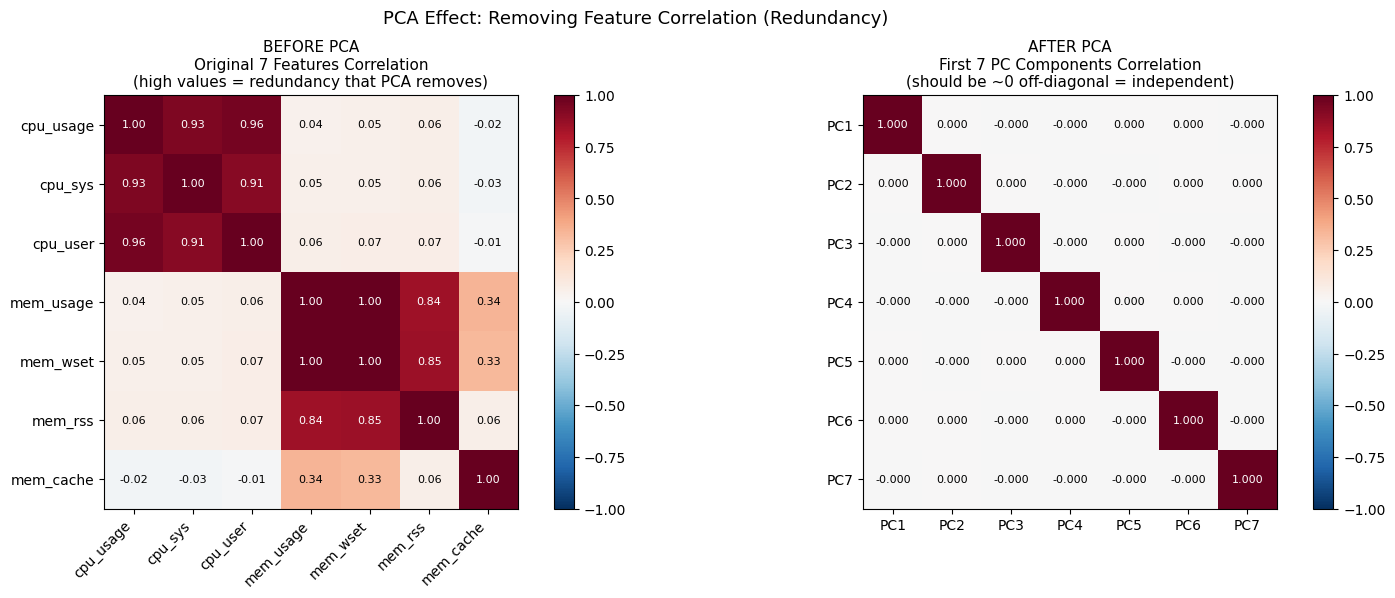

Left : high off-diagonal values = features share info (redundancy exists)
Right: ~0 off-diagonal values  = PCA components are independent


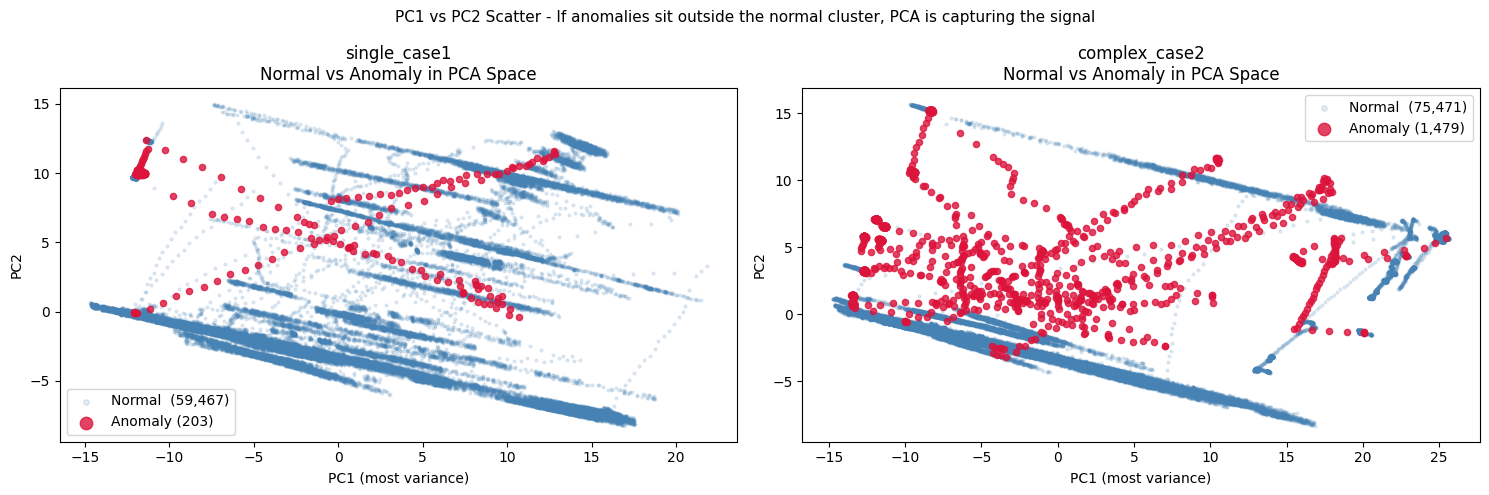


PCA VERIFICATION CHECKS
  Components used       : 28  (out of 210)
  Variance retained     : 95.12%
  Variance discarded    : 4.88%
  Compression ratio     : 210 -> 28  (7.5x smaller)

  Reconstruction MSE (normal training windows):
    Mean : 0.052579
    Max  : 0.588938
    Std  : 0.040068

  Max off-diagonal PCA component correlation:
    0.000000  (ideal = 0.0, anything < 0.01 is correct)

  Conclusion:
  [PASS] Variance retained >= 95%
  [PASS] PCA components are orthogonal (correlation ~ 0)
  [PASS] Reconstruction MSE is low (data well-preserved)


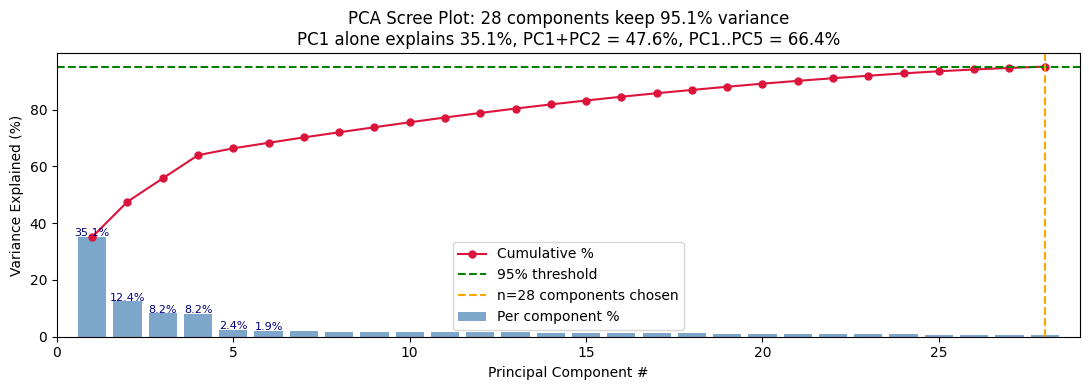

In [73]:
# === 1. CORRELATION HEATMAP: original 7 features vs PCA components ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

short_labels = ["cpu_usage", "cpu_sys", "cpu_user",
                "mem_usage", "mem_wset", "mem_rss", "mem_cache"]

# Left: correlation of original 7 features (training normal rows)
train_rows = df[(df["case"] == "single_case1") & (df["label"] == 0)][FEATURE_COLS]
corr_raw   = train_rows.rename(columns=dict(zip(FEATURE_COLS, short_labels))).corr().values

im1 = axes[0].imshow(corr_raw, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(short_labels, rotation=45, ha="right")
axes[0].set_yticks(range(7))
axes[0].set_yticklabels(short_labels)
axes[0].set_title("BEFORE PCA\nOriginal 7 Features Correlation\n(high values = redundancy that PCA removes)", fontsize=11)
for i in range(7):
    for j in range(7):
        v = corr_raw[i, j]
        axes[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if abs(v) > 0.7 else "black")
plt.colorbar(im1, ax=axes[0])

# Right: correlation of first 7 PCA components (must be ~0 off-diagonal)
X_pca_tr  = case_windows["single_case1"]["X_pca"][normal_mask]
pc_labels = [f"PC{i+1}" for i in range(7)]
corr_pca  = pd.DataFrame(X_pca_tr[:, :7], columns=pc_labels).corr().values

im2 = axes[1].imshow(corr_pca, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(pc_labels)
axes[1].set_yticks(range(7))
axes[1].set_yticklabels(pc_labels)
axes[1].set_title("AFTER PCA\nFirst 7 PC Components Correlation\n(should be ~0 off-diagonal = independent)", fontsize=11)
for i in range(7):
    for j in range(7):
        v = corr_pca[i, j]
        axes[1].text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8,
                     color="white" if abs(v) > 0.7 else "black")
plt.colorbar(im2, ax=axes[1])

plt.suptitle("PCA Effect: Removing Feature Correlation (Redundancy)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pca_correlation.png"), dpi=100)
plt.show()
print("Left : high off-diagonal values = features share info (redundancy exists)")
print("Right: ~0 off-diagonal values  = PCA components are independent")


# === 2. PC1 vs PC2 SCATTER: normal vs anomaly separation ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, case_name in zip(axes, ["single_case1", "complex_case2"]):
    Xp = case_windows[case_name]["X_pca"]
    yp = case_windows[case_name]["y"]
    ax.scatter(Xp[yp == 0, 0], Xp[yp == 0, 1],
               alpha=0.15, s=4, color="steelblue", label=f"Normal  ({(yp==0).sum():,})")
    ax.scatter(Xp[yp == 1, 0], Xp[yp == 1, 1],
               alpha=0.8, s=20, color="crimson", label=f"Anomaly ({(yp==1).sum():,})")
    ax.set_xlabel("PC1 (most variance)")
    ax.set_ylabel("PC2")
    ax.set_title(f"{case_name}\nNormal vs Anomaly in PCA Space")
    ax.legend(markerscale=2)

plt.suptitle("PC1 vs PC2 Scatter - If anomalies sit outside the normal cluster, PCA is capturing the signal", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pca_scatter.png"), dpi=100)
plt.show()


# === 3. RECONSTRUCTION CHECK: how much info did we lose? ===
X_flat_normal   = case_windows["single_case1"]["X_flat"][normal_mask]
X_reconstructed = pca.inverse_transform(X_pca_tr)         # decompress 28 -> 210
mse_per_sample  = np.mean((X_flat_normal - X_reconstructed) ** 2, axis=1)
off_diag        = corr_pca.copy()
np.fill_diagonal(off_diag, 0)

print()
print("=" * 55)
print("PCA VERIFICATION CHECKS")
print("=" * 55)
print(f"  Components used       : {pca.n_components_}  (out of 210)")
print(f"  Variance retained     : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  Variance discarded    : {(1 - pca.explained_variance_ratio_.sum())*100:.2f}%")
print(f"  Compression ratio     : 210 -> {pca.n_components_}  ({210/pca.n_components_:.1f}x smaller)")
print()
print("  Reconstruction MSE (normal training windows):")
print(f"    Mean : {mse_per_sample.mean():.6f}")
print(f"    Max  : {mse_per_sample.max():.6f}")
print(f"    Std  : {mse_per_sample.std():.6f}")
print()
print("  Max off-diagonal PCA component correlation:")
print(f"    {abs(off_diag).max():.6f}  (ideal = 0.0, anything < 0.01 is correct)")
print()
print("  Conclusion:")
if pca.explained_variance_ratio_.sum() >= 0.95:
    print("  [PASS] Variance retained >= 95%")
else:
    print("  [FAIL] Variance < 95%, consider more components")
if abs(off_diag).max() < 0.01:
    print("  [PASS] PCA components are orthogonal (correlation ~ 0)")
else:
    print("  [WARN] Some PCA components are correlated")
if mse_per_sample.mean() < 0.5:
    print("  [PASS] Reconstruction MSE is low (data well-preserved)")
else:
    print("  [WARN] High reconstruction MSE, more components may help")


# === 4. EXPLAINED VARIANCE PLOT (clearer version) ===
fig, ax = plt.subplots(figsize=(11, 4))
ev_ratio = pca.explained_variance_ratio_ * 100
cumvar   = np.cumsum(ev_ratio)
x_idx    = range(1, len(ev_ratio) + 1)

ax.bar(x_idx, ev_ratio, color="steelblue", alpha=0.7, label="Per component %")
ax.plot(x_idx, cumvar, color="crimson", marker="o", markersize=5, label="Cumulative %")
ax.axhline(95, color="green", linestyle="--", linewidth=1.5, label="95% threshold")
ax.axvline(pca.n_components_, color="orange", linestyle="--", linewidth=1.5,
           label=f"n={pca.n_components_} components chosen")

for i, ev in enumerate(ev_ratio[:6]):
    ax.text(i + 1, ev + 0.3, f"{ev:.1f}%", ha="center", fontsize=8, color="navy")

ax.set_xlabel("Principal Component #")
ax.set_ylabel("Variance Explained (%)")
ax.set_title(
    f"PCA Scree Plot: {pca.n_components_} components keep {cumvar[-1]:.1f}% variance\n"
    f"PC1 alone explains {ev_ratio[0]:.1f}%, "
    f"PC1+PC2 = {cumvar[1]:.1f}%, "
    f"PC1..PC5 = {cumvar[4]:.1f}%"
)
ax.legend()
ax.set_xlim(0, min(50, len(ev_ratio) + 1))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pca_explained_variance.png"), dpi=100)
plt.show()


---
## Step 5 â€” Train / Val / Test Splits

In [74]:
sc1 = case_windows['single_case1']
sc2 = case_windows['single_case2']
cc1 = case_windows['complex_case1']
cc2 = case_windows['complex_case2']

normal_mask  = sc1['y'] == 0

# Train: single_case1 normal windows only (VAE trains on normal behavior)
X_train = sc1['X_pca'][normal_mask]
y_train = sc1['y'][normal_mask]

# Val: single_case2 all windows (tune detection threshold)
X_val   = sc2['X_pca']
y_val   = sc2['y']

# Test simple: single_case1 + single_case2 full (in-distribution anomaly evaluation)
X_test_simple = np.concatenate([sc1['X_pca'], sc2['X_pca']], axis=0)
y_test_simple = np.concatenate([sc1['y'],     sc2['y']],     axis=0)
ft_test_simple = np.concatenate([sc1['ft'],   sc2['ft']],    axis=0)

# Test drift: complex_case1 + complex_case2 (concept drift evaluation)
X_test_drift  = np.concatenate([cc1['X_pca'], cc2['X_pca']], axis=0)
y_test_drift  = np.concatenate([cc1['y'],     cc2['y']],     axis=0)
ft_test_drift = np.concatenate([cc1['ft'],    cc2['ft']],    axis=0)

print('Split summary:')
print(f'  X_train       : {X_train.shape}   <- VAE trains here (normal only)')
print(f'  X_val         : {X_val.shape}   <- threshold tuning')
print(f'  X_test_simple : {X_test_simple.shape}   <- in-distribution test')
print(f'  X_test_drift  : {X_test_drift.shape}  <- concept drift test')
print()
print('Anomaly windows:')
print(f'  y_train        : {y_train.sum()}  (must be 0 â€” training on normal only)')
print(f'  y_val          : {y_val.sum()}  ({y_val.mean()*100:.2f}%)')
print(f'  y_test_simple  : {y_test_simple.sum()}  ({y_test_simple.mean()*100:.2f}%)')
print(f'  y_test_drift   : {y_test_drift.sum()}  ({y_test_drift.mean()*100:.2f}%)')

Split summary:
  X_train       : (59467, 28)   <- VAE trains here (normal only)
  X_val         : (38043, 28)   <- threshold tuning
  X_test_simple : (97713, 28)   <- in-distribution test
  X_test_drift  : (298445, 28)  <- concept drift test

Anomaly windows:
  y_train        : 0  (must be 0 â€” training on normal only)
  y_val          : 85  (0.22%)
  y_test_simple  : 288  (0.29%)
  y_test_drift   : 2262  (0.76%)


---
## Step 6 â€” Save All Outputs

In [75]:
saves = {
    'X_train'       : X_train,
    'y_train'       : y_train,
    'X_val'         : X_val,
    'y_val'         : y_val,
    'X_test_simple' : X_test_simple,
    'y_test_simple' : y_test_simple,
    'X_test_drift'  : X_test_drift,
    'y_test_drift'  : y_test_drift,
    'ft_test_simple': ft_test_simple,
    'ft_test_drift' : ft_test_drift,
}

for name, arr in saves.items():
    path = os.path.join(OUT_DIR, f'{name}.npy')
    np.save(path, arr)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f'  Saved {name:22s}: shape={str(arr.shape):20s}  {size_mb:.1f} MB')

print(f'\nPCA model : {OUT_DIR}/pca_model.pkl')

  Saved X_train               : shape=(59467, 28)           6.4 MB
  Saved y_train               : shape=(59467,)              0.1 MB
  Saved X_val                 : shape=(38043, 28)           4.1 MB
  Saved y_val                 : shape=(38043,)              0.0 MB
  Saved X_test_simple         : shape=(97713, 28)           10.4 MB
  Saved y_test_simple         : shape=(97713,)              0.1 MB
  Saved X_test_drift          : shape=(298445, 28)          31.9 MB
  Saved y_test_drift          : shape=(298445,)             0.3 MB
  Saved ft_test_simple        : shape=(97713,)              0.8 MB
  Saved ft_test_drift         : shape=(298445,)             2.6 MB

PCA model : c:\Users\jthar\Documents\Claude\Projects\module3\data\processed\windows/pca_model.pkl


---
## Step 7 Final Verification

In [76]:
print('=== FINAL VERIFICATION ===')
print()
for name in ['X_train','X_val','X_test_simple','X_test_drift']:
    arr = np.load(os.path.join(OUT_DIR, f'{name}.npy'))
    print(f'  {name:22s}: shape={arr.shape}  dtype={arr.dtype}  NaNs={np.isnan(arr).sum()}')

X_tr = np.load(os.path.join(OUT_DIR, 'X_train.npy'))
print(f'\nX_train value range : [{X_tr.min():.4f},  {X_tr.max():.4f}]')
print(f'X_train mean / std  : {X_tr.mean():.4f} / {X_tr.std():.4f}')
print(f'NaNs in X_train     : {np.isnan(X_tr).sum()}  (must be 0)')

=== FINAL VERIFICATION ===

  X_train               : shape=(59467, 28)  dtype=float32  NaNs=0
  X_val                 : shape=(38043, 28)  dtype=float32  NaNs=0
  X_test_simple         : shape=(97713, 28)  dtype=float32  NaNs=0
  X_test_drift          : shape=(298445, 28)  dtype=float32  NaNs=0

X_train value range : [-14.6702,  21.8194]
X_train mean / std  : 0.0000 / 2.7724
NaNs in X_train     : 0  (must be 0)


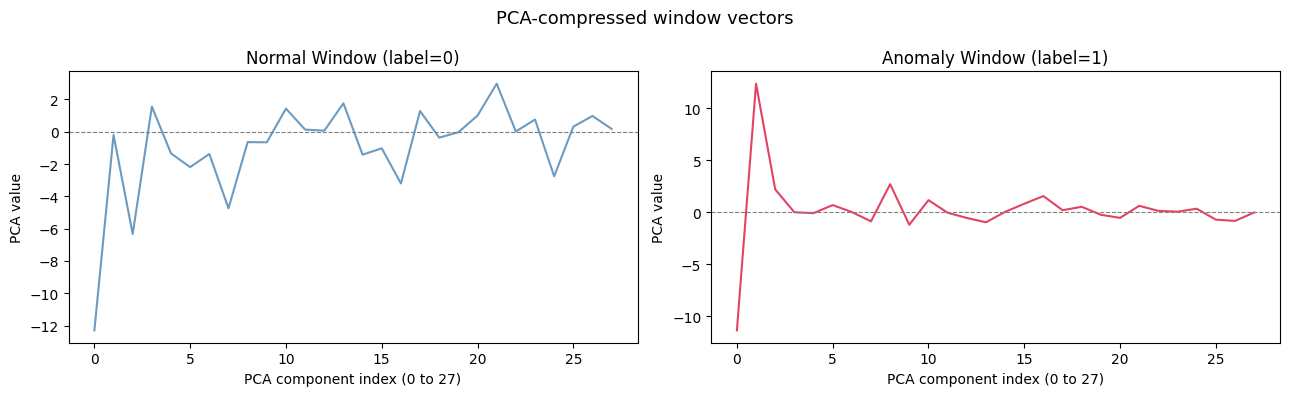

In [77]:
# Visualize normal vs anomaly window (first 2 PCA components)
X_ts = np.load(os.path.join(OUT_DIR, 'X_test_simple.npy'))
y_ts = np.load(os.path.join(OUT_DIR, 'y_test_simple.npy'))

normal_idx  = np.where(y_ts == 0)[0][0]
anomaly_idx = np.where(y_ts == 1)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, idx, title, color in zip(
    axes,
    [normal_idx, anomaly_idx],
    ['Normal Window (label=0)', 'Anomaly Window (label=1)'],
    ['steelblue', 'crimson']
):
    ax.plot(X_ts[idx], color=color, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f'PCA component index (0 to {n_components-1})')
    ax.set_ylabel('PCA value')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('PCA-compressed window vectors', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'sample_windows.png'), dpi=100)
plt.show()

In [78]:
print('\n=== PREPROCESSING COMPLETE ===')
print(f'\nAll files saved to: {OUT_DIR}')
print()
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f)) / (1024 * 1024)
    print(f'  {f:30s}  {size:.1f} MB')

print()
print('Next step: Load X_train.npy into the VAE.')
print(f'  VAE input size = {n_components}  (PCA components per window)')


=== PREPROCESSING COMPLETE ===

All files saved to: c:\Users\jthar\Documents\Claude\Projects\module3\data\processed\windows

  X_test_drift.npy                31.9 MB
  X_test_simple.npy               10.4 MB
  X_train.npy                     6.4 MB
  X_val.npy                       4.1 MB
  ft_test_drift.npy               2.6 MB
  ft_test_simple.npy              0.8 MB
  pca_correlation.png             0.1 MB
  pca_explained_variance.png      0.0 MB
  pca_model.pkl                   0.0 MB
  pca_scatter.png                 0.2 MB
  pca_variance.png                0.0 MB
  sample_windows.png              0.0 MB
  window_label_distribution.png   0.0 MB
  y_test_drift.npy                0.3 MB
  y_test_simple.npy               0.1 MB
  y_train.npy                     0.1 MB
  y_val.npy                       0.0 MB

Next step: Load X_train.npy into the VAE.
  VAE input size = 28  (PCA components per window)


---
## Output Files Summary

| File | Shape | Description |
|---|---|---|
| `X_train.npy` | (N, n_pc) | Normal windows only â€” VAE training input |
| `y_train.npy` | (N,) | All zeros |
| `X_val.npy` | (N, n_pc) | All single_case2 windows |
| `y_val.npy` | (N,) | Labels for val set |
| `X_test_simple.npy` | (N, n_pc) | single_case1 + single_case2 |
| `y_test_simple.npy` | (N,) | Labels |
| `X_test_drift.npy` | (N, n_pc) | complex_case1 + complex_case2 |
| `y_test_drift.npy` | (N,) | Labels |
| `ft_test_simple.npy` | (N,) | Failure types for test |
| `ft_test_drift.npy` | (N,) | Failure types for drift test |
| `pca_model.pkl` | â€” | Fitted PCA â€” apply to new windows |

### Load in VAE Notebook
```python
import numpy as np, joblib

X_train = np.load('data/processed/windows/X_train.npy')  # shape: (N, n_components)
X_val   = np.load('data/processed/windows/X_val.npy')
y_val   = np.load('data/processed/windows/y_val.npy')

pca = joblib.load('data/processed/windows/pca_model.pkl')

# To preprocess a new raw window at inference time:
# new_window shape: (30, 7)  ->  flatten -> (210,)  ->  pca.transform -> (n_components,)
new_window_pca = pca.transform(new_window.flatten().reshape(1, -1))
```